In [1]:
# =========================================
# Credit Risk Prediction - Give Me Some Credit
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.over_sampling import SMOTE

In [2]:
#load dataset
train = pd.read_csv("cs-training.csv")
test = pd.read_csv("cs-test.csv")

train.drop("Unnamed: 0", axis=1, inplace=True)
test.drop("Unnamed: 0", axis=1, inplace=True)

train.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
#dataset overview
print(train.shape)
print(train.info())
train.describe()

(150000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [4]:
#missing values
train.isnull().sum().sort_values(ascending=False)

MonthlyIncome                           29731
NumberOfDependents                       3924
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
dtype: int64

In [5]:
# Filling training data
train['MonthlyIncome'] = train['MonthlyIncome'].fillna(train['MonthlyIncome'].median())
train['NumberOfDependents'] = train['NumberOfDependents'].fillna(train['NumberOfDependents'].median())

# Filling test data 
test['MonthlyIncome'] = test['MonthlyIncome'].fillna(train['MonthlyIncome'].median())
test['NumberOfDependents'] = test['NumberOfDependents'].fillna(train['NumberOfDependents'].median())

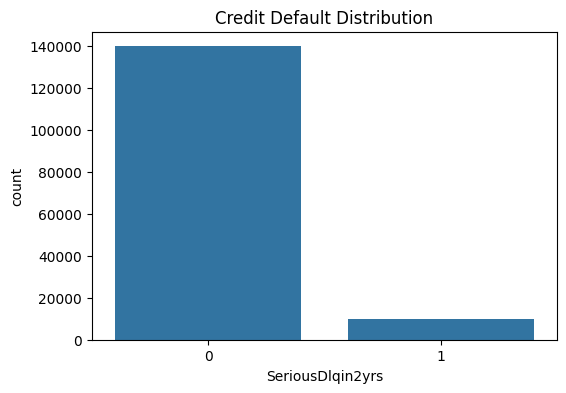

In [6]:
#exploratory data analysis
#target distribution
plt.figure(figsize=(6,4))
sns.countplot(x="SeriousDlqin2yrs", data=train)
plt.title("Credit Default Distribution")
plt.show()

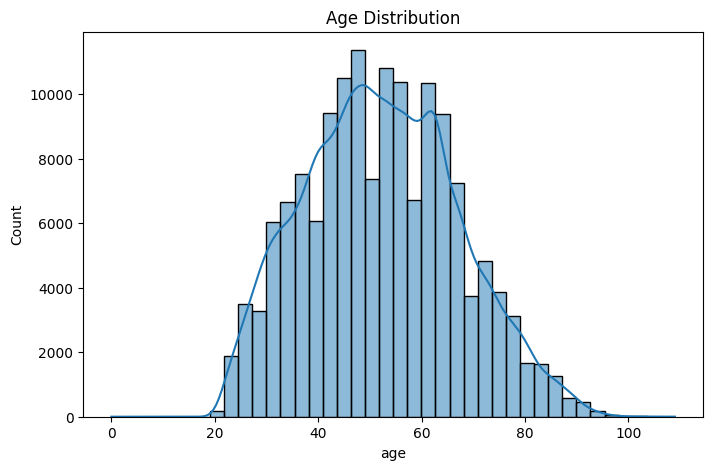

In [7]:
#age distribution
plt.figure(figsize=(8,5))
sns.histplot(train['age'], bins=40, kde=True)
plt.title("Age Distribution")
plt.show()

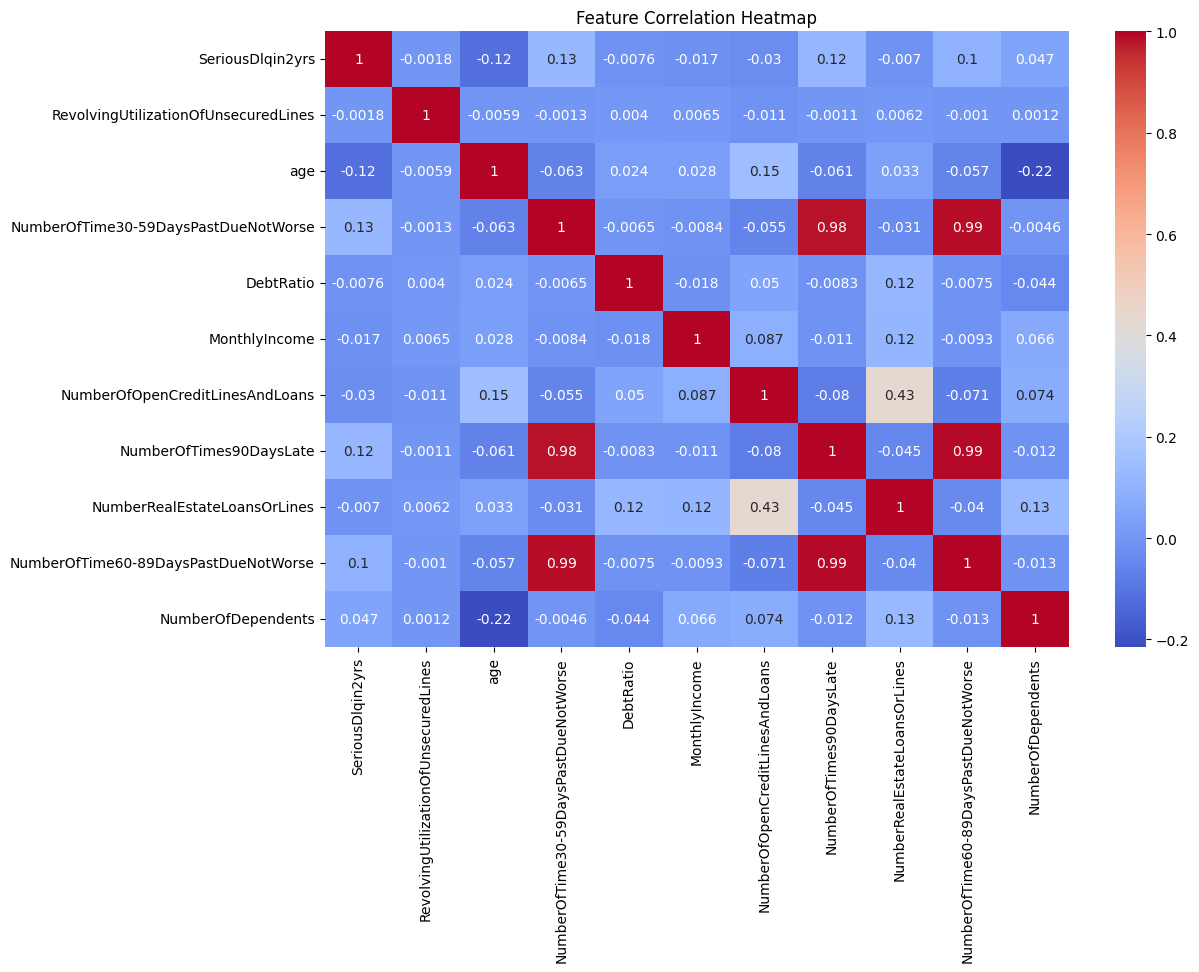

In [8]:
#correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

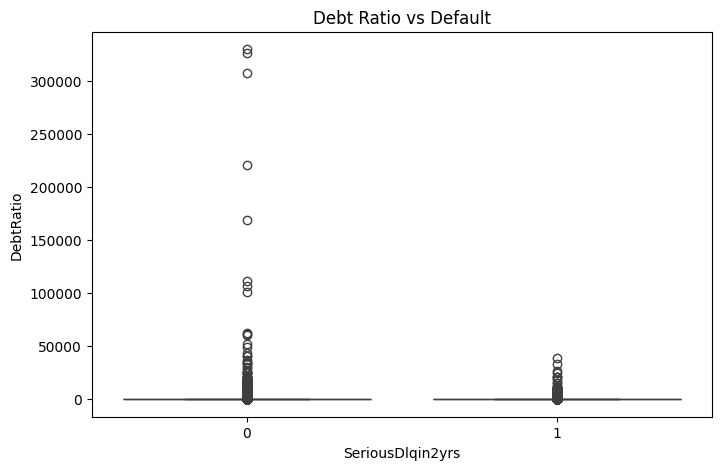

In [9]:
#debt ratio vs default
plt.figure(figsize=(8,5))
sns.boxplot(x='SeriousDlqin2yrs', y='DebtRatio', data=train)
plt.title("Debt Ratio vs Default")
plt.show()

In [10]:
#data cleaning
train = train[train['age'] > 18]
train = train[train['RevolvingUtilizationOfUnsecuredLines'] < 2]
train = train[train['DebtRatio'] < 5]

In [11]:
#feature engineering
train['TotalLatePayments'] = (
    train['NumberOfTime30-59DaysPastDueNotWorse'] +
    train['NumberOfTime60-89DaysPastDueNotWorse'] +
    train['NumberOfTimes90DaysLate']
)

train['IncomePerDependent'] = train['MonthlyIncome'] / (train['NumberOfDependents'] + 1)

In [12]:
test['TotalLatePayments'] = (
    test['NumberOfTime30-59DaysPastDueNotWorse'] +
    test['NumberOfTime60-89DaysPastDueNotWorse'] +
    test['NumberOfTimes90DaysLate']
)

test['IncomePerDependent'] = test['MonthlyIncome'] / (test['NumberOfDependents'] + 1)

In [13]:
#train test split
X = train.drop("SeriousDlqin2yrs", axis=1)
y = train["SeriousDlqin2yrs"]

In [14]:
#handle imbalanced data
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [15]:
#logistic regression
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000))
])

pipe.fit(X_res, y_res)

,steps,"[('scaler', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [16]:
#random forest
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_res, y_res)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
#gradient boosting
gb = GradientBoostingClassifier()
gb.fit(X_res, y_res)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [24]:
#model comparison
models = {
    "Logistic Regression": pipe,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    scores = cross_val_score(model, X_res, y_res, cv=5, scoring='roc_auc')
    print(name, "ROC AUC:", scores.mean())

Logistic Regression ROC AUC: 0.8571340815304607
Random Forest ROC AUC: 0.9591766681489711
Gradient Boosting ROC AUC: 0.8873847813889194


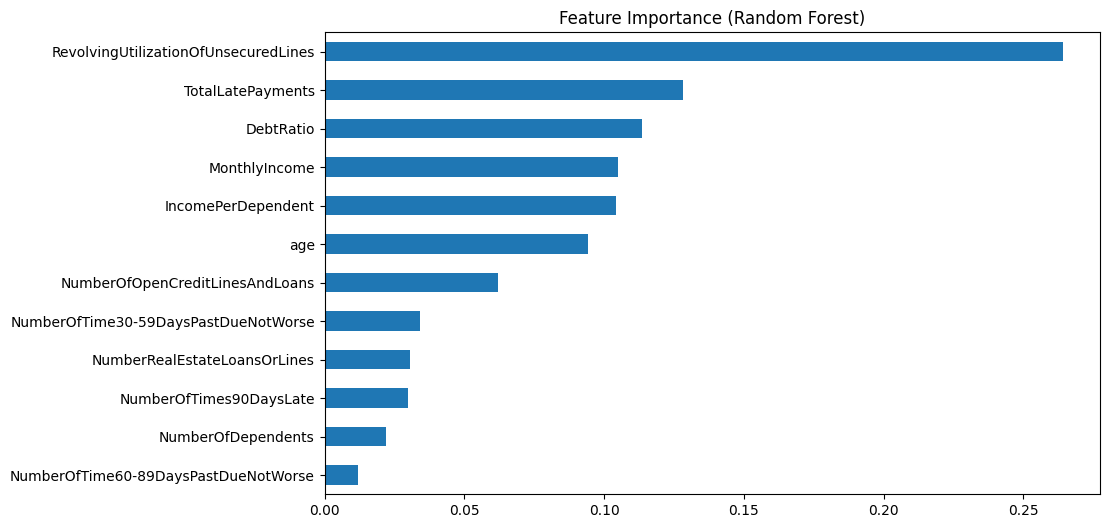

In [17]:
#feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure(figsize=(10,6))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.show()

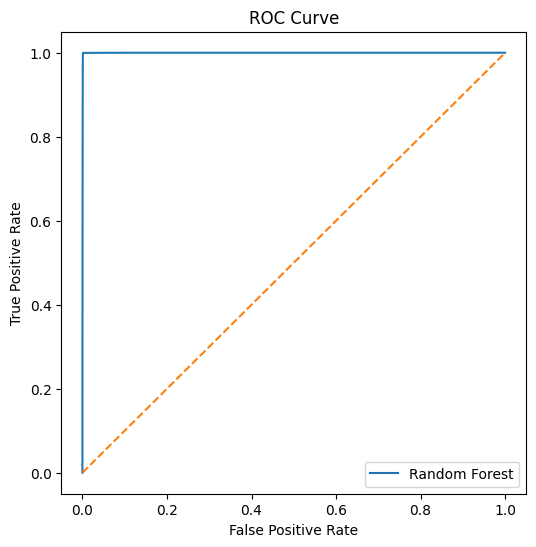

In [18]:
#ROC curve
y_pred = rf.predict_proba(X)[:,1]

fpr, tpr, _ = roc_curve(y, y_pred)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [27]:
#test prediction
test = test.drop(["SeriousDlqin2yrs"], axis=1)

test = test[X.columns]

test_predictions = rf.predict_proba(test)[:,1]

In [28]:
test.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,TotalLatePayments,IncomePerDependent
0,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0,0,5700.000000
1,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0,0,3047.000000
2,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0,0,1694.333333
3,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0,1,3200.000000
4,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0,0,1932.500000


In [30]:
test_predictions

array([0.14666667, 0.12      , 0.08666667, ..., 0.24666667, 0.46333333,
       0.23333333], shape=(101503,))

In [ ]:
#SHAP explainability
#commented to reduce runtime
#import shap

#explainer = shap.TreeExplainer(rf)
#shap_values = explainer.shap_values(X)

#shap.summary_plot(shap_values, X)


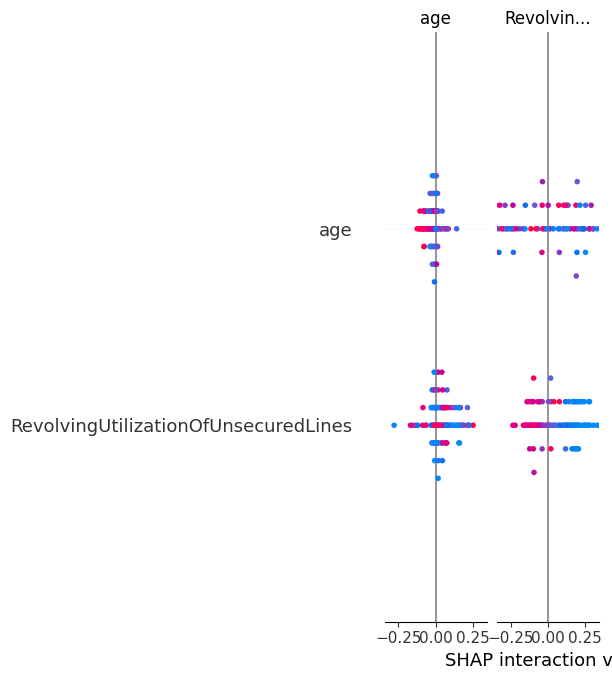

In [18]:
import shap
sample_X = X.head(100)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(sample_X)

shap.summary_plot(shap_values, sample_X)


In [33]:
#submission file
submission = pd.DataFrame({
    "Id": test.index + 1,
    "Probability": test_predictions
})

submission.to_csv("submission.csv", index=False)

In [34]:
submission


,Id,Probability
0,1,0.146667
1,2,0.120000
2,3,0.086667
3,4,0.143333
4,5,0.180000
...,...,...
101498,101499,0.366667
101499,101500,0.660000
101500,101501,0.246667
101501,101502,0.463333


In [21]:
#adding hyperparameter tuning
##commented to reduce runtime
#from sklearn.model_selection import GridSearchCV

#param_grid = {'n_estimators':[200,300,400],'max_depth':[5,10,15],'min_samples_split':[2,5]}

#grid = GridSearchCV(RandomForestClassifier(),param_grid,cv=5,scoring='roc_auc')

#grid.fit(X_res, y_res)

#print(grid.best_params_)
#print(grid.best_score_)

In [17]:
#adding confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

y_pred = rf.predict(X)

print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

[[111439    160]
 [     7   8329]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    111599
           1       0.98      1.00      0.99      8336

    accuracy                           1.00    119935
   macro avg       0.99      1.00      0.99    119935
weighted avg       1.00      1.00      1.00    119935



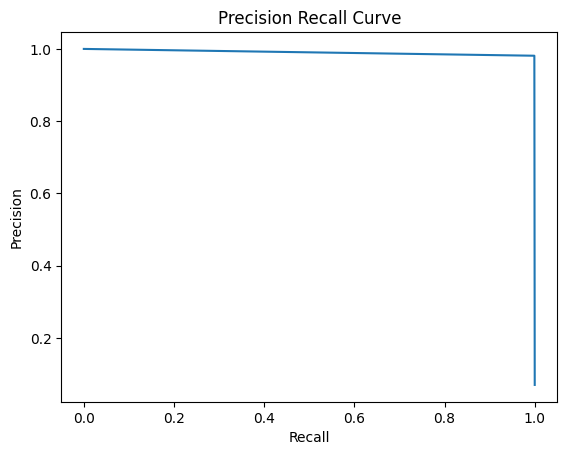

In [18]:
#adding precision call curve
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y, y_pred)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()

In [19]:
#save model
import joblib

joblib.dump(rf,"credit_risk_model.pkl")

['credit_risk_model.pkl']

In [20]:
#build simple prediction function
def predict_default(data):
    model = joblib.load("credit_risk_model.pkl")
    prob = model.predict_proba(data)[:,1]
    return prob